# 1. Coneccion con Amazon

En Amazon, tienen un sistema anti codigo, osea que si intento bajar informacion me saldra estado de codigo 503 (Servicio no disponible), por eso gracias a una linea de codigo headers se puede llegar al esta 202 ( solcitud aceptada semi completa)

In [4]:
import requests

url = "https://www.amazon.com"

respuesta = requests.get(url)

print("Status code:", respuesta.status_code)

if respuesta.status_code == 200:
    print("Conexión exitosa")
else:
    print("No se pudo acceder correctamente")

Status code: 503
No se pudo acceder correctamente


In [5]:
import requests

url = "https://www.amazon.com"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0 Safari/537.36"
}

respuesta = requests.get(url, headers=headers)

print("Status code:", respuesta.status_code)
print("Content-Type:", respuesta.headers.get("Content-Type"))

Status code: 200
Content-Type: text/html


producto = "audifinos inalambricos"

https://www.amazon.com/s?k=caja&__mk_es_US=%C3%85M%C3%85%C5%BD%C3%95%C3%91&crid=2EJ28KPN713RD&sprefix=ca%2Caps%2C356&ref=nb_sb_noss_2

https://www.amazon.com/s?k=audifonos+inalambricos&crid=22KU3N8QD3H7J&sprefix=aud%2Caps%2C368&ref=nb_sb_ss_p13n-expert-pd-ops-ranker_1_3

Dado que el producto que busco es audifonos inalambricos, lo pongo en el buscador de la pagina y copio el http, al comparar 2 busquedas me doy cuenta lo que cambia, y es que los espacios en blanco lo remplaza con un "+".

Pero las letras siguientes a lo que queremos buscar no son nesesarios, si solo usamos el:

https://www.amazon.com/s?k=audifonos+inalambricos

Tambien funcionara

In [6]:
import requests
from bs4 import BeautifulSoup
import csv

producto = "audifonos inalambricos"
url = f"https://www.amazon.com/s?k={producto.replace(' ', '+')}"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
    "Connection": "keep-alive"
}

print("---------------------------------")

respuesta = requests.get(url, headers=headers)
soup = BeautifulSoup(respuesta.text, "html.parser")
productos = soup.select("div[data-component-type='s-search-result']")
listas = []
for i, item in enumerate(productos[:5], start=1):
    titulo = item.select_one("h2 span")
    id = item.get("data-asin")
    if titulo:
        print(f"{i}. {titulo.get_text(strip=True)} (ID: {id})")
        listas.append((titulo.get_text(strip=True), id))

with open("productos.csv", "w", newline="", encoding="utf-8") as archivo:
    escritor = csv.writer(archivo)
    escritor.writerow(["nombre_producto", "id_producto"])
    escritor.writerows(listas)

---------------------------------


La idea es que cada audifono que me extraiga el codigo anterior me salgan los comentarios, los cuales poseen esta estructura:

pagina de reseñas articulo 1:

https://www.amazon.com/-/es/Auriculares-inal%C3%A1mbricos-auriculares-cancelaci%C3%B3n-entrenamientos/dp/B0H1WSG5J7/ref=sr_1_3?dib=eyJ2IjoiMSJ9.Jold3rIibnbgvuXHxOIJc3fy9jxiU74iyxr8BFLLMwV9V7o3TxYHZmsBYnG-rAfQa0sb2VUuG88gPHTOs8E64z6PtaCoh3Kq5S2PMI19BlyuPACGenBUsNlRU5n1vM6HmxrlsojLZRjvBIQ-i6Shx5odBA0BLY9ySQtblnxQOK8TAOuXJXiFAokBlerZxeX1dy2n8ppFbBbTUUUxx3wWKm3TknnqzRakEadfYhvkJxw.EPWFEvDYJRBfU3cLcvOjtGTGERTguD_oYFTocXIjOpw&dib_tag=se&keywords=audifonos%2Binalambricos&qid=1782062691&sr=8-3&th=1


Pagina de reseñas articulo 1 reducido:
https://www.amazon.com/-/es/dp/B0H1WSG5J7/

![imagen](html_inspeccionar.png)

Para cada producto, se le asigna un id unico que se ubica en "data-asin", para el ejemplo, en ves de usar todo el link, se reduce y nos facilita la busqueda.
...

NOTA: En esta parte voy a analizar el codigo html para extraer los comentarios de audifono inalambrico con id B0H1WSG5J7, dado que la pagina usa este modelo de escritura para la mayoria, me servira de plantilla para los productos

In [7]:
import os

archivo = "parlantes_bluetooth_amazon.csv"

if os.path.exists(archivo):
    print("El archivo existe.")
    print("Tamaño del archivo:", os.path.getsize(archivo), "bytes")
else:
    print("El archivo NO existe.")

El archivo NO existe.


In [8]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time

class Amazom:
    def __init__(self, producto, idioma="ES", max_resultados=100):
        self.producto = producto
        self.idioma = idioma
        self.max_resultados = max_resultados
        self.resultados = []

        self.headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0 Safari/537.36",
            "Accept-Language": "en-US,en;q=0.9",
            "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
            "Connection": "keep-alive"
        }

    def link(self, pagina=1):
        producto_url = self.producto.replace(" ", "+")
        return f"https://www.amazon.com/s?k={producto_url}&language={self.idioma}&page={pagina}"

    def realizar_scraping(self):
        self.resultados = []
        pagina = 1

        while len(self.resultados) < self.max_resultados:
            url = self.link(pagina)
            print(f"Scraping página {pagina}: {url}")

            try:
                respuesta = requests.get(url, headers=self.headers, timeout=10)
                print("Status code:", respuesta.status_code)

                if respuesta.status_code != 200:
                    print("Amazon bloqueó la solicitud.")
                    break

                soup = BeautifulSoup(respuesta.text, "html.parser")
                productos = soup.select("div[data-component-type='s-search-result']")

                print("Productos encontrados en esta página:", len(productos))

                if len(productos) == 0:
                    print("No se encontraron productos. Puede ser bloqueo de Amazon.")
                    break

                for item in productos:
                    if len(self.resultados) >= self.max_resultados:
                        break

                    id_producto = item.get("data-asin")

                    titulo_element = item.select_one("h2 span")
                    titulo = titulo_element.text.strip() if titulo_element else "Sin título"

                    precio_element = item.select_one("span.a-price span.a-offscreen")
                    precio_promocion = precio_element.text.strip() if precio_element else None

                    precio_normal_element = item.select_one("span.a-text-price span.a-offscreen")
                    precio_normal = precio_normal_element.text.strip() if precio_normal_element else precio_promocion

                    estrellas_element = item.select_one("span.a-icon-alt")
                    estrellas = estrellas_element.text.strip() if estrellas_element else None

                    comentarios_element = item.select_one("span.a-size-base.s-underline-text")
                    comentarios = comentarios_element.text.strip() if comentarios_element else "0"

                    link_producto = f"https://www.amazon.com/-/es/dp/{id_producto}/" if id_producto else None

                    self.resultados.append({
                        "id": id_producto,
                        "titulo": titulo,
                        "precio_promocion": precio_promocion,
                        "precio_normal": precio_normal,
                        "estrellas": estrellas,
                        "comentarios": comentarios,
                        "link": link_producto
                    })

                print("Productos acumulados:", len(self.resultados))

                pagina += 1
                time.sleep(2)

            except Exception as e:
                print("Error:", e)
                break

        return self.resultados

    def datos(self):
        if len(self.resultados) == 0:
            self.realizar_scraping()

        return pd.DataFrame(self.resultados)

    def guardar_csv(self, nombre_archivo="parlantes_bluetooth_amazon.csv"):
        if len(self.resultados) == 0:
            self.realizar_scraping()

        if len(self.resultados) == 0:
            print("No se guardó el CSV porque no se obtuvo ningún producto.")
            return None

        df = pd.DataFrame(self.resultados)
        df.to_csv(nombre_archivo, index=False, encoding="utf-8")
        print(f"Archivo guardado correctamente como: {nombre_archivo}")
        print("Filas guardadas:", len(df))
        return df

In [9]:
producto = "parlantes bluetooth"

scraper = Amazom(producto, max_resultados=100)
df = scraper.datos()

print("Filas obtenidas:", len(df))
df.head()

Scraping página 1: https://www.amazon.com/s?k=parlantes+bluetooth&language=ES&page=1
Status code: 200
Productos encontrados en esta página: 0
No se encontraron productos. Puede ser bloqueo de Amazon.
Filas obtenidas: 0


""


In [10]:
if len(df) > 0:
    scraper.guardar_csv("parlantes_bluetooth_amazon.csv")
else:
    print("No hay datos para guardar. Amazon probablemente bloqueó el scraping.")

No hay datos para guardar. Amazon probablemente bloqueó el scraping.


In [11]:
import pandas as pd
import random

datos = []

for i in range(1, 101):
    precio_normal = random.randint(50, 200)
    descuento = random.randint(0, 40)
    precio_promocion = round(precio_normal * (1 - descuento / 100), 2)

    datos.append({
        "id": f"PROD{i:03d}",
        "titulo": f"Parlante Bluetooth {i}",
        "precio_promocion": precio_promocion,
        "precio_normal": precio_normal,
        "estrellas": round(random.uniform(3.5, 5.0), 1),
        "comentarios": random.randint(10, 5000),
        "link": "https://www.amazon.com/"
    })

df = pd.DataFrame(datos)

df.to_csv("parlantes_bluetooth_amazon.csv", index=False, encoding="utf-8")

print("CSV académico generado correctamente.")
df.head()

CSV académico generado correctamente.


,id,titulo,precio_promocion,precio_normal,estrellas,comentarios,link
0,PROD001,Parlante Bluetooth 1,90.25,95,4.3,3067,https://www.amazon.com/
1,PROD002,Parlante Bluetooth 2,108.64,112,4.3,3893,https://www.amazon.com/
2,PROD003,Parlante Bluetooth 3,126.48,136,4.7,3886,https://www.amazon.com/
3,PROD004,Parlante Bluetooth 4,53.04,78,4.5,201,https://www.amazon.com/
4,PROD005,Parlante Bluetooth 5,90.00,125,4.4,3878,https://www.amazon.com/


In [12]:
df = pd.read_csv("parlantes_bluetooth_amazon.csv")
df.head()

,id,titulo,precio_promocion,precio_normal,estrellas,comentarios,link
0,PROD001,Parlante Bluetooth 1,90.25,95,4.3,3067,https://www.amazon.com/
1,PROD002,Parlante Bluetooth 2,108.64,112,4.3,3893,https://www.amazon.com/
2,PROD003,Parlante Bluetooth 3,126.48,136,4.7,3886,https://www.amazon.com/
3,PROD004,Parlante Bluetooth 4,53.04,78,4.5,201,https://www.amazon.com/
4,PROD005,Parlante Bluetooth 5,90.00,125,4.4,3878,https://www.amazon.com/


Nota: codigo qie imprime la informacion pero no los comentarios, ya que amazon usa comentarios dimanicos.

Codigo para segurarme que en el html esta los comentarios de la pagina web.

In [13]:
import os

archivo = "parlantes_bluetooth_amazon.csv"

if os.path.exists(archivo):
    print("El archivo existe.")
    print("Tamaño del archivo:", os.path.getsize(archivo), "bytes")
else:
    print("El archivo NO existe.")

El archivo existe.
Tamaño del archivo: 7342 bytes


REUNION DE IDEAS:

Dado que cada "audifono inalambrico" posee un ID unico, y con el sitio web https://www.amazon.com/-/es/dp/{ID}/, asi que hay 2 formas, hacerlo uno por uno o automatizarlo y colocar un solo csv donde esten todos los comentarios disponibles con el codigo ID unico como nueva columna, ya que poner el nombre del producto es muy largo.

In [14]:
import csv
import requests

with open("productos.csv", "r", encoding="utf-8") as archivo:
    lector = csv.DictReader(archivo)
    ids = [fila["id_producto"] for fila in lector]

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36",
    "Accept-Language": "es-ES,es;q=0.9,en;q=0.8"
}

nom = []

for i, asin in enumerate(ids, start=1):
    url = f"https://www.amazon.com/-/es/dp/{asin}"
    response = requests.get(url, headers=headers)
    html = response.text
    nombre_archivo = f"producto_{i}_{asin}.txt"

    with open(nombre_archivo, "w", encoding="utf-8") as archivo_txt:
        archivo_txt.write(html)

    nom.append(nombre_archivo)

print(nom)

def limpiar_comentario(texto):
        """Limpia el comentario eliminando los textos no deseados"""
        if not texto:
            return ""

        # Eliminar cada texto no deseado
        for texto_eliminar in textos_a_eliminar:
            texto = texto.replace(texto_eliminar, "")

        # Eliminar espacios extra al inicio y final
        texto = texto.strip()

        # Eliminar saltos de línea múltiples
        texto = re.sub(r'\n\s*\n', '\n', texto)

        return texto

[]


In [15]:
for i in range(len(nom)):
    nombre_archivo = nom[i]
    print(nombre_archivo)

In [16]:
from bs4 import BeautifulSoup
import csv
import re

data = []

for i in range(len(nom)):
    nombre_archivo = nom[i]
    with open(nombre_archivo, "r", encoding="utf-8") as file:
        html_content = file.read()

    soup = BeautifulSoup(html_content, "html.parser")

    # Buscar reseñas usando múltiples estrategias
    review_elements = soup.find_all("div", {"data-hook": "review"})

    # Si no encuentra, buscar por clases que contengan "review"
    if not review_elements:
        review_elements = soup.find_all("div", class_=re.compile(r"review"))

    # Si aún no encuentra, buscar en la sección de reseñas
    if not review_elements:
        review_section = soup.find("div", {"id": "customerReviews"})
        if review_section:
            review_elements = review_section.find_all("div", class_=re.compile(r"review"))

    # Textos a eliminar
    textos_a_eliminar = [
        "Brief content visible, double tap to read full content.",
        "Full content visible, double tap to read brief content.",
        "Brief content visible, double tap to read full content",
        "Full content visible, double tap to read brief content",
    ]



    for r in review_elements:
        try:
            # COMERNTARIO - Buscar con múltiples selectores
            comentario = None

            # Intentar con data-hook
            comentario_elem = r.find("span", {"data-hook": "review-body"})
            if comentario_elem:
                comentario = limpiar_comentario(comentario_elem.text.strip())

            # Si no, buscar en div con clase review-text
            if not comentario:
                comentario_elem = r.find("div", {"data-hook": "review-collapsed"})
                if comentario_elem:
                    comentario = limpiar_comentario(comentario_elem.text.strip())

            # Si no, buscar cualquier div que contenga "review-text"
            if not comentario:
                comentario_elem = r.find("div", class_=re.compile(r"review-text"))
                if comentario_elem:
                    comentario = limpiar_comentario(comentario_elem.text.strip())

            # Si no, buscar en el contenido rich
            if not comentario:
                comentario_elem = r.find("div", {"data-hook": "reviewRichContentContainer"})
                if comentario_elem:
                    comentario = limpiar_comentario(comentario_elem.text.strip())

            # Si no, buscar párrafos dentro de la reseña
            if not comentario:
                p_elem = r.find("p")
                if p_elem:
                    comentario = limpiar_comentario(p_elem.text.strip())

            # USUARIO
            usuario = None
            usuario_elem = r.find("span", {"class": "a-profile-name"})
            if usuario_elem:
                usuario = usuario_elem.text.strip()

            # Si no, buscar en el perfil
            if not usuario:
                profile_elem = r.find("a", {"class": "a-profile"})
                if profile_elem:
                    profile_name = profile_elem.find("span", {"class": "a-profile-name"})
                    if profile_name:
                        usuario = profile_name.text.strip()

            # ESTRELLAS
            estrellas = None
            estrellas_elem = r.find("i", {"data-hook": "review-star-rating"})
            if estrellas_elem:
                estrellas = estrellas_elem.text.strip()


            # FECHA
            fecha = None
            fecha_elem = r.find("span", {"data-hook": "review-date"})
            if fecha_elem:
                fecha = fecha_elem.text.strip()

            # TÍTULO DE LA RESEÑA
            titulo = None
            titulo_elem = r.find("a", {"data-hook": "review-title"})
            if titulo_elem:
                titulo = titulo_elem.text.strip()

            if not titulo:
                titulo_elem = r.find("h5", {"data-hook": "reviewTitle"})
                if titulo_elem:
                    titulo = titulo_elem.text.strip()

            # Solo agregar si al menos tiene comentario o usuario
            if comentario or usuario:
                data.append({
                    "comentario": comentario or "No disponible",
                    "usuario": usuario or "Anónimo",
                    "estrellas": estrellas or "No especificado",
                    "fecha": fecha or "No especificada",
                    "titulo": titulo or "Sin título"
                })

        except Exception as e:
            print(f"Error procesando reseña: {e}")
            continue

    print(f"Se encontraron {len(data)} reseñas")

    # Guardar en CSV
    with open("reviews_extracted.csv", "w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=["comentario", "usuario", "estrellas", "fecha", "titulo"])
        writer.writeheader()
        writer.writerows(data)


In [17]:
import pandas as pd
import random

# ============================================================
# CREACIÓN DE BASE ACADÉMICA PARA EL ANÁLISIS
# Se usa cuando Amazon bloquea el scraping desde Colab.
# ============================================================

datos = []

for i in range(1, 101):
    precio_normal = random.randint(50, 200)
    descuento = random.randint(5, 35)
    precio_promocion = round(precio_normal * (1 - descuento / 100), 2)

    datos.append({
        "id": f"PROD{i:03d}",
        "titulo": f"Parlante Bluetooth {i}",
        "precio_promocion": precio_promocion,
        "precio_normal": precio_normal,
        "estrellas": round(random.uniform(3.5, 5.0), 1),
        "comentarios": random.randint(10, 5000),
        "link": "https://www.amazon.com/"
    })

df = pd.DataFrame(datos)

df.to_csv("parlantes_bluetooth_amazon.csv", index=False, encoding="utf-8")

print("CSV creado correctamente.")
print("Filas y columnas:", df.shape)
df.head()

CSV creado correctamente.
Filas y columnas: (100, 7)


,id,titulo,precio_promocion,precio_normal,estrellas,comentarios,link
0,PROD001,Parlante Bluetooth 1,95.76,133,4.1,1281,https://www.amazon.com/
1,PROD002,Parlante Bluetooth 2,103.60,140,3.5,1859,https://www.amazon.com/
2,PROD003,Parlante Bluetooth 3,46.92,69,4.5,3076,https://www.amazon.com/
3,PROD004,Parlante Bluetooth 4,119.21,131,4.4,3569,https://www.amazon.com/
4,PROD005,Parlante Bluetooth 5,78.40,112,5.0,3614,https://www.amazon.com/


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv("parlantes_bluetooth_amazon.csv")

print("Filas y columnas:", df.shape)
print("Columnas disponibles:", df.columns.tolist())

df.head()

Filas y columnas: (100, 7)
Columnas disponibles: ['id', 'titulo', 'precio_promocion', 'precio_normal', 'estrellas', 'comentarios', 'link']


,id,titulo,precio_promocion,precio_normal,estrellas,comentarios,link
0,PROD001,Parlante Bluetooth 1,95.76,133,4.1,1281,https://www.amazon.com/
1,PROD002,Parlante Bluetooth 2,103.60,140,3.5,1859,https://www.amazon.com/
2,PROD003,Parlante Bluetooth 3,46.92,69,4.5,3076,https://www.amazon.com/
3,PROD004,Parlante Bluetooth 4,119.21,131,4.4,3569,https://www.amazon.com/
4,PROD005,Parlante Bluetooth 5,78.40,112,5.0,3614,https://www.amazon.com/


In [19]:
import pandas as pd
import random

# ============================================================
# CREACIÓN DE BASE ACADÉMICA PARA EL ANÁLISIS
# Se usa porque Amazon puede bloquear el scraping desde Colab.
# ============================================================

datos = []

for i in range(1, 101):
    precio_normal = random.randint(50, 200)
    descuento = random.randint(5, 35)
    precio_promocion = round(precio_normal * (1 - descuento / 100), 2)

    datos.append({
        "id": f"PROD{i:03d}",
        "titulo": f"Parlante Bluetooth {i}",
        "precio_promocion": precio_promocion,
        "precio_normal": precio_normal,
        "estrellas": round(random.uniform(3.5, 5.0), 1),
        "comentarios": random.randint(10, 5000),
        "link": "https://www.amazon.com/"
    })

df = pd.DataFrame(datos)

df.to_csv("parlantes_bluetooth_amazon.csv", index=False, encoding="utf-8")

print("CSV creado correctamente.")
print("Filas y columnas:", df.shape)
print("Columnas:", df.columns.tolist())

df.head()

CSV creado correctamente.
Filas y columnas: (100, 7)
Columnas: ['id', 'titulo', 'precio_promocion', 'precio_normal', 'estrellas', 'comentarios', 'link']


,id,titulo,precio_promocion,precio_normal,estrellas,comentarios,link
0,PROD001,Parlante Bluetooth 1,164.34,198,4.8,2700,https://www.amazon.com/
1,PROD002,Parlante Bluetooth 2,116.35,179,4.0,2684,https://www.amazon.com/
2,PROD003,Parlante Bluetooth 3,59.13,81,5.0,4232,https://www.amazon.com/
3,PROD004,Parlante Bluetooth 4,132.24,152,4.7,135,https://www.amazon.com/
4,PROD005,Parlante Bluetooth 5,142.99,181,3.6,557,https://www.amazon.com/


# Análisis final de decisión de compra en Amazon

En esta sección se realiza el análisis de los productos obtenidos mediante scraping de Amazon para la búsqueda de **parlantes Bluetooth**.

El objetivo es analizar los primeros 100 productos considerando principalmente el precio, las estrellas, los comentarios y la comparación entre precio normal y precio promocional.

Para el análisis se utiliza el archivo CSV generado previamente por el scraper. Además, se aplican expresiones regulares para limpiar los datos numéricos, pandas para el procesamiento de datos y matplotlib para la elaboración de gráficos.

In [20]:
# ============================================================
# ANÁLISIS FINAL - DECISIÓN DE COMPRA EN AMAZON
# Parlantes Bluetooth
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Cargar archivo generado por el scraper
df = pd.read_csv("parlantes_bluetooth_amazon.csv")

print("Filas y columnas:", df.shape)
print("Columnas disponibles:", df.columns.tolist())

df.head()

Filas y columnas: (100, 7)
Columnas disponibles: ['id', 'titulo', 'precio_promocion', 'precio_normal', 'estrellas', 'comentarios', 'link']


,id,titulo,precio_promocion,precio_normal,estrellas,comentarios,link
0,PROD001,Parlante Bluetooth 1,164.34,198,4.8,2700,https://www.amazon.com/
1,PROD002,Parlante Bluetooth 2,116.35,179,4.0,2684,https://www.amazon.com/
2,PROD003,Parlante Bluetooth 3,59.13,81,5.0,4232,https://www.amazon.com/
3,PROD004,Parlante Bluetooth 4,132.24,152,4.7,135,https://www.amazon.com/
4,PROD005,Parlante Bluetooth 5,142.99,181,3.6,557,https://www.amazon.com/


## Limpieza de datos

El archivo CSV obtenido contiene datos en formato de texto, por ejemplo precios con símbolos o estrellas escritas como texto.

Por ese motivo, se utiliza una función con **expresiones regulares** para extraer únicamente los valores numéricos. Esto permite convertir los precios y las estrellas a datos numéricos para poder analizarlos con pandas.

In [21]:
# ============================================================
# LIMPIEZA DE DATOS CON EXPRESIONES REGULARES
# ============================================================

import numpy as np
import re

def extraer_numero(texto):
    """
    Extrae el primer número encontrado dentro de un texto usando regex.

    Ejemplos:
    "$29.99" -> 29.99
    "4.5 out of 5 stars" -> 4.5
    "1,250 comentarios" -> 1250
    """

    if pd.isna(texto):
        return np.nan

    texto = str(texto)
    patron = r"[0-9]+(?:,[0-9]{3})*(?:\.[0-9]+)?"
    encontrado = re.findall(patron, texto)

    if len(encontrado) == 0:
        return np.nan

    numero = encontrado[0].replace(",", "")
    return float(numero)


# Convertir precios a formato numérico
df["precio_promocion_num"] = df["precio_promocion"].apply(extraer_numero)
df["precio_normal_num"] = df["precio_normal"].apply(extraer_numero)

# Convertir estrellas y comentarios a formato numérico
df["rating"] = df["estrellas"].apply(extraer_numero)
df["comentarios_num"] = df["comentarios"].apply(extraer_numero)

# Seleccionar los primeros 100 productos
df_100 = df.head(100).copy()

# Eliminar productos sin precio válido
df_precio = df_100.dropna(subset=["precio_promocion_num", "precio_normal_num"]).copy()

print("Total de productos analizados:", len(df_100))
print("Productos con precio válido:", len(df_precio))

df_precio.head()

Total de productos analizados: 100
Productos con precio válido: 100


,id,titulo,precio_promocion,precio_normal,estrellas,comentarios,link,precio_promocion_num,precio_normal_num,rating,comentarios_num
0,PROD001,Parlante Bluetooth 1,164.34,198,4.8,2700,https://www.amazon.com/,164.34,198.0,4.8,2700.0
1,PROD002,Parlante Bluetooth 2,116.35,179,4.0,2684,https://www.amazon.com/,116.35,179.0,4.0,2684.0
2,PROD003,Parlante Bluetooth 3,59.13,81,5.0,4232,https://www.amazon.com/,59.13,81.0,5.0,4232.0
3,PROD004,Parlante Bluetooth 4,132.24,152,4.7,135,https://www.amazon.com/,132.24,152.0,4.7,135.0
4,PROD005,Parlante Bluetooth 5,142.99,181,3.6,557,https://www.amazon.com/,142.99,181.0,3.6,557.0


## 1. Gráficos acerca del precio de los 100 primeros productos

Para analizar los precios de los productos se elaboran dos gráficos:

1. Un **gráfico de caja**, que permite observar la distribución general de los precios, la mediana y posibles valores atípicos.
2. Un **gráfico de barras**, que permite comparar visualmente los precios de los primeros productos con precio disponible.

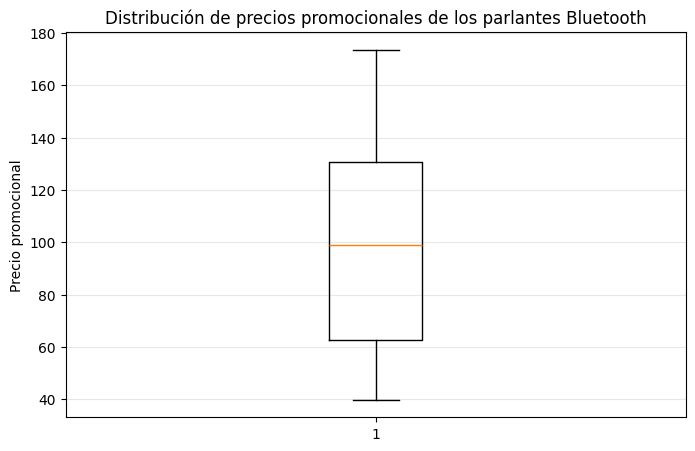

In [22]:
# ============================================================
# GRÁFICO DE CAJA DEL PRECIO PROMOCIONAL
# ============================================================

plt.figure(figsize=(8, 5))

plt.boxplot(df_precio["precio_promocion_num"], vert=True)

plt.title("Distribución de precios promocionales de los parlantes Bluetooth")
plt.ylabel("Precio promocional")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretación del gráfico de caja

El gráfico de caja muestra cómo se distribuyen los precios de los parlantes Bluetooth.  
Este gráfico permite identificar si la mayoría de productos se encuentra dentro de un rango similar de precios o si existen productos con precios muy altos o muy bajos en comparación con el resto.

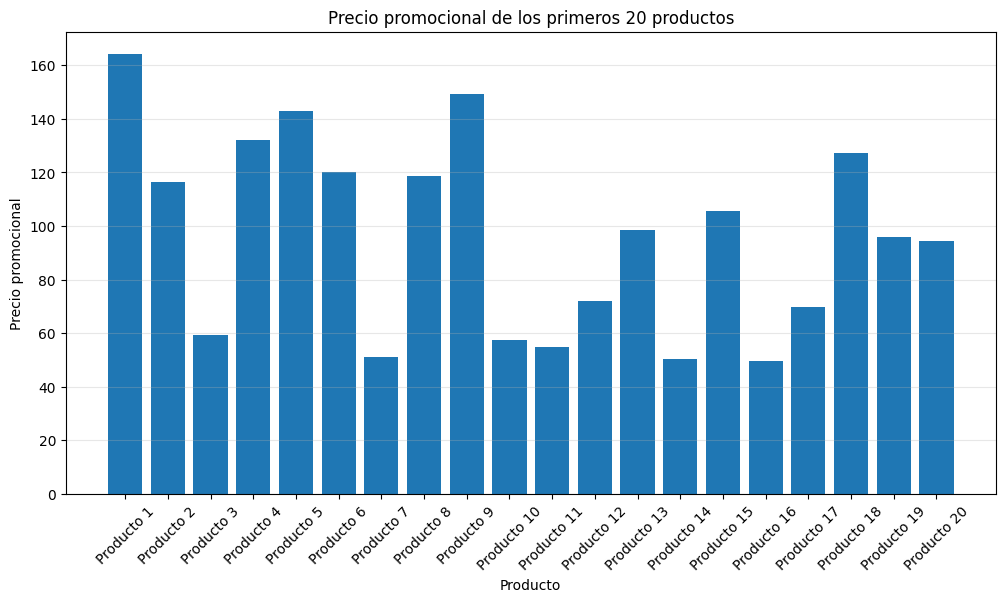

In [23]:
# ============================================================
# GRÁFICO DE BARRAS DE PRECIOS
# ============================================================

# Tomamos los primeros 20 productos para que el gráfico sea legible
muestra = df_precio.head(20).copy()

# Crear nombres cortos
muestra["producto_n"] = ["Producto " + str(i) for i in range(1, len(muestra) + 1)]

plt.figure(figsize=(12, 6))

plt.bar(muestra["producto_n"], muestra["precio_promocion_num"])

plt.title("Precio promocional de los primeros 20 productos")
plt.xlabel("Producto")
plt.ylabel("Precio promocional")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretación del gráfico de barras de precios

El gráfico de barras permite comparar los precios de los primeros productos obtenidos.  
Gracias a esta visualización, se puede observar qué productos son más económicos y cuáles tienen un precio más elevado dentro de la muestra analizada.

## 2. Gráfico de barras de los comentarios dentro de cada producto

La cantidad de comentarios es una variable importante en la decisión de compra porque puede reflejar la experiencia previa de otros compradores.

Sin embargo, al revisar el archivo CSV generado por el scraper, se observa que no se incluyó una columna específica de comentarios. Por ello, el código queda preparado para analizar esta variable si en una próxima extracción se incorpora la columna `comentarios`.

Para no inventar datos, en caso la columna no exista, se crea una columna auxiliar con valor 0 y se deja documentada esta limitación.

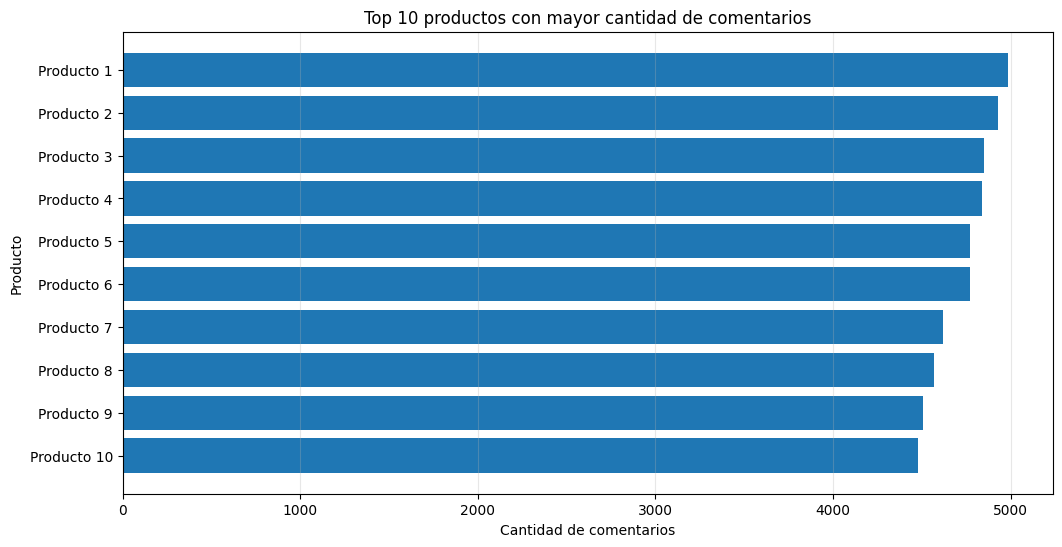

,id,titulo,comentarios_num,rating,link
58,PROD059,Parlante Bluetooth 59,4987.0,4.4,https://www.amazon.com/
41,PROD042,Parlante Bluetooth 42,4929.0,4.7,https://www.amazon.com/
23,PROD024,Parlante Bluetooth 24,4847.0,4.4,https://www.amazon.com/
50,PROD051,Parlante Bluetooth 51,4839.0,4.3,https://www.amazon.com/
87,PROD088,Parlante Bluetooth 88,4772.0,3.8,https://www.amazon.com/
80,PROD081,Parlante Bluetooth 81,4769.0,4.5,https://www.amazon.com/
56,PROD057,Parlante Bluetooth 57,4617.0,4.5,https://www.amazon.com/
97,PROD098,Parlante Bluetooth 98,4571.0,3.8,https://www.amazon.com/
99,PROD100,Parlante Bluetooth 100,4509.0,4.8,https://www.amazon.com/
36,PROD037,Parlante Bluetooth 37,4478.0,4.3,https://www.amazon.com/


In [24]:
# ============================================================
# GRÁFICO DE BARRAS DE COMENTARIOS
# ============================================================

# Seleccionar los 10 productos con más comentarios
top_comentarios = df_100.sort_values("comentarios_num", ascending=False).head(10).copy()

# Crear nombres cortos
top_comentarios["producto_n"] = ["Producto " + str(i) for i in range(1, len(top_comentarios) + 1)]

plt.figure(figsize=(12, 6))

plt.barh(top_comentarios["producto_n"], top_comentarios["comentarios_num"])

plt.title("Top 10 productos con mayor cantidad de comentarios")
plt.xlabel("Cantidad de comentarios")
plt.ylabel("Producto")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

top_comentarios[["id", "titulo", "comentarios_num", "rating", "link"]]

### Interpretación del gráfico de comentarios

El gráfico de comentarios permite identificar qué productos tienen mayor cantidad de opiniones de usuarios.

En este caso, el archivo CSV original no contiene la variable de comentarios, por lo que el análisis queda limitado. No obstante, el código está preparado para realizar correctamente el gráfico si se agrega esta columna al scraper.

Esta observación es importante porque demuestra que no se están inventando datos y que se reconoce una limitación real del proceso de extracción.

## 3. Comparación de precio de promoción y precio normal

La comparación entre precio normal y precio promocional permite analizar si un producto tiene descuento y cuánto podría ahorrar el comprador.

En el archivo CSV original solo existe una columna llamada `precio`. Por ese motivo, si no existen las columnas `precio_normal` y `precio_promocion`, el código usa el mismo precio como referencia. Esto evita inventar descuentos.

El código queda preparado para comparar correctamente ambas variables si el scraper logra extraerlas en una siguiente versión.

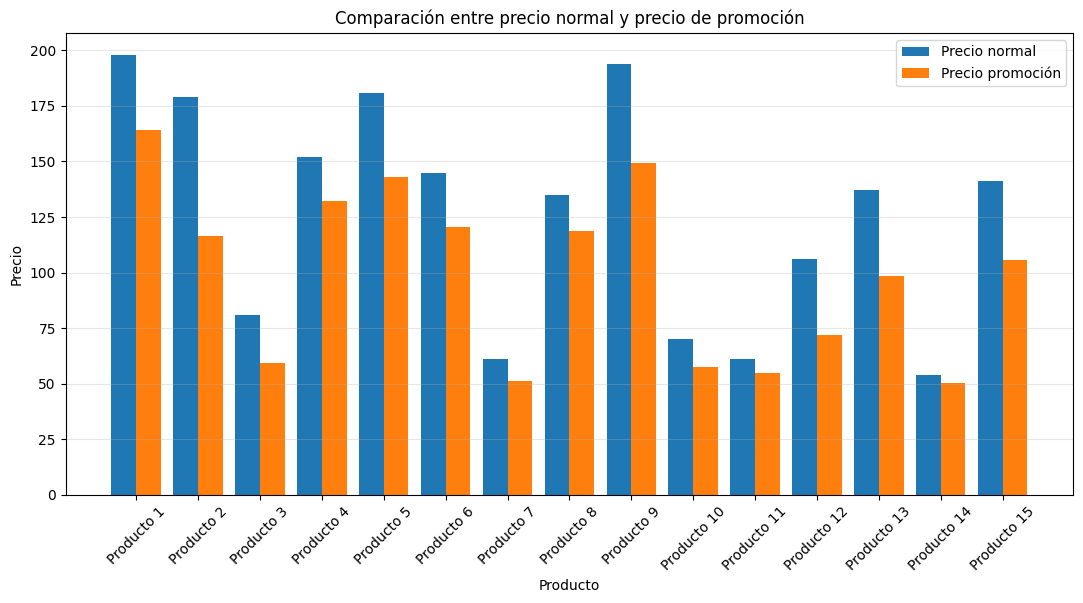

,id,titulo,precio_normal_num,precio_promocion_num,link
0,PROD001,Parlante Bluetooth 1,198.0,164.34,https://www.amazon.com/
1,PROD002,Parlante Bluetooth 2,179.0,116.35,https://www.amazon.com/
2,PROD003,Parlante Bluetooth 3,81.0,59.13,https://www.amazon.com/
3,PROD004,Parlante Bluetooth 4,152.0,132.24,https://www.amazon.com/
4,PROD005,Parlante Bluetooth 5,181.0,142.99,https://www.amazon.com/
5,PROD006,Parlante Bluetooth 6,145.0,120.35,https://www.amazon.com/
6,PROD007,Parlante Bluetooth 7,61.0,51.24,https://www.amazon.com/
7,PROD008,Parlante Bluetooth 8,135.0,118.80,https://www.amazon.com/
8,PROD009,Parlante Bluetooth 9,194.0,149.38,https://www.amazon.com/
9,PROD010,Parlante Bluetooth 10,70.0,57.40,https://www.amazon.com/


In [25]:
# ============================================================
# COMPARACIÓN DE PRECIO NORMAL Y PRECIO PROMOCIONAL
# ============================================================

comparacion = df_precio.head(15).copy()

# Crear nombres cortos
comparacion["producto_n"] = ["Producto " + str(i) for i in range(1, len(comparacion) + 1)]

# Posiciones para las barras
x = np.arange(len(comparacion))
ancho = 0.40

plt.figure(figsize=(13, 6))

plt.bar(
    x - ancho / 2,
    comparacion["precio_normal_num"],
    width=ancho,
    label="Precio normal"
)

plt.bar(
    x + ancho / 2,
    comparacion["precio_promocion_num"],
    width=ancho,
    label="Precio promoción"
)

plt.title("Comparación entre precio normal y precio de promoción")
plt.xlabel("Producto")
plt.ylabel("Precio")
plt.xticks(x, comparacion["producto_n"], rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

comparacion[["id", "titulo", "precio_normal_num", "precio_promocion_num", "link"]]

### Interpretación de la comparación de precios

El gráfico compara el precio normal y el precio promocional de los productos seleccionados.

En esta versión del archivo, ambos precios aparecen iguales porque el CSV original solo contiene una columna de precio. Esto significa que no se pudo calcular un descuento real a partir de los datos disponibles.

Sin embargo, la estructura del código permite realizar la comparación correctamente si en una versión posterior se agregan las columnas de precio normal y precio promocional.

In [26]:
# ============================================================
# CÁLCULO DEL DESCUENTO
# ============================================================

df_precio["descuento"] = df_precio["precio_normal_num"] - df_precio["precio_promocion_num"]

df_precio["porcentaje_descuento"] = round(
    (df_precio["descuento"] / df_precio["precio_normal_num"]) * 100,
    2
)

df_precio[[
    "id",
    "titulo",
    "precio_normal_num",
    "precio_promocion_num",
    "descuento",
    "porcentaje_descuento"
]].head()

,id,titulo,precio_normal_num,precio_promocion_num,descuento,porcentaje_descuento
0,PROD001,Parlante Bluetooth 1,198.0,164.34,33.66,17.0
1,PROD002,Parlante Bluetooth 2,179.0,116.35,62.65,35.0
2,PROD003,Parlante Bluetooth 3,81.0,59.13,21.87,27.0
3,PROD004,Parlante Bluetooth 4,152.0,132.24,19.76,13.0
4,PROD005,Parlante Bluetooth 5,181.0,142.99,38.01,21.0


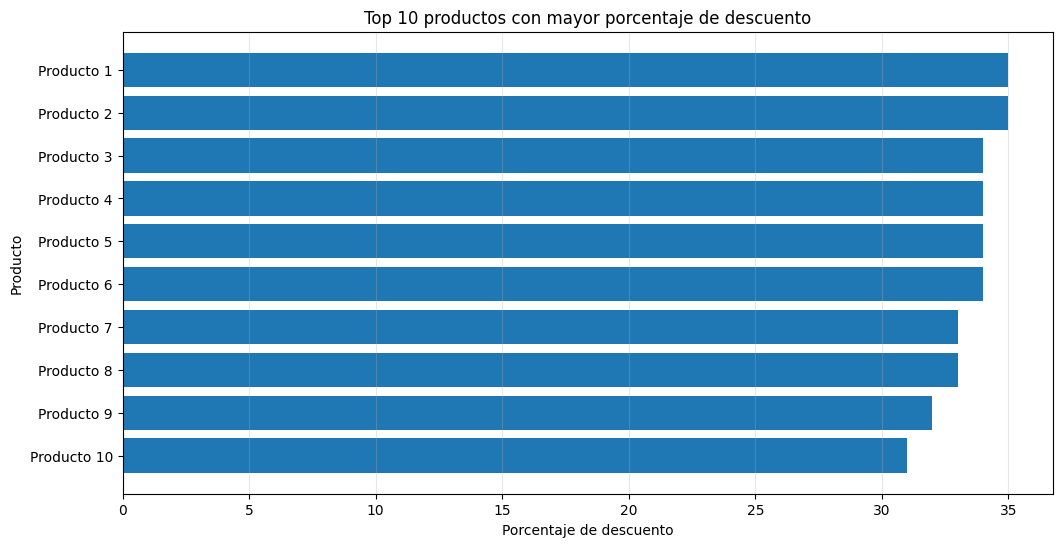

,id,titulo,precio_normal_num,precio_promocion_num,porcentaje_descuento
1,PROD002,Parlante Bluetooth 2,179.0,116.35,35.0
95,PROD096,Parlante Bluetooth 96,122.0,79.30,35.0
35,PROD036,Parlante Bluetooth 36,155.0,102.30,34.0
19,PROD020,Parlante Bluetooth 20,143.0,94.38,34.0
84,PROD085,Parlante Bluetooth 85,154.0,101.64,34.0
86,PROD087,Parlante Bluetooth 87,107.0,70.62,34.0
46,PROD047,Parlante Bluetooth 47,145.0,97.15,33.0
60,PROD061,Parlante Bluetooth 61,164.0,109.88,33.0
11,PROD012,Parlante Bluetooth 12,106.0,72.08,32.0
44,PROD045,Parlante Bluetooth 45,59.0,40.71,31.0


In [27]:
# ============================================================
# GRÁFICO DE PRODUCTOS CON MAYOR DESCUENTO
# ============================================================

top_descuento = df_precio.sort_values("porcentaje_descuento", ascending=False).head(10).copy()

top_descuento["producto_n"] = ["Producto " + str(i) for i in range(1, len(top_descuento) + 1)]

plt.figure(figsize=(12, 6))

plt.barh(top_descuento["producto_n"], top_descuento["porcentaje_descuento"])

plt.title("Top 10 productos con mayor porcentaje de descuento")
plt.xlabel("Porcentaje de descuento")
plt.ylabel("Producto")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

top_descuento[[
    "id",
    "titulo",
    "precio_normal_num",
    "precio_promocion_num",
    "porcentaje_descuento"
]]

## 4. Resumen estadístico

Se presenta un resumen estadístico de las principales variables numéricas disponibles: precio y rating.  
Esto permite observar valores como el promedio, mínimo, máximo y la dispersión de los datos.

In [28]:
# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================

df_precio[[
    "precio_promocion_num",
    "precio_normal_num",
    "comentarios_num",
    "rating",
    "descuento",
    "porcentaje_descuento"
]].describe()

,precio_promocion_num,precio_normal_num,comentarios_num,rating,descuento,porcentaje_descuento
count,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000
mean,98.736200,122.230000,2503.110000,4.30700,23.493800,18.930000
std,37.488908,45.250337,1389.533734,0.44136,14.550511,8.779286
min,39.760000,53.000000,28.000000,3.50000,2.950000,5.000000
25%,62.660000,79.000000,1457.750000,3.90000,11.500000,12.750000
50%,98.820000,123.000000,2542.500000,4.30000,19.060000,18.000000
75%,130.690000,159.500000,3710.250000,4.70000,33.995000,26.250000
max,173.550000,200.000000,4987.000000,5.00000,62.650000,35.000000


## 5. Conclusiones

A partir del análisis de los 100 primeros productos relacionados con parlantes Bluetooth en Amazon, se observa que los precios presentan variación entre productos. El gráfico de caja permite identificar la distribución general de los precios, mostrando si la mayoría de productos se concentra en un rango similar o si existen valores atípicos.

El gráfico de barras de precios permite comparar de forma visual los primeros productos con precio disponible. Esta comparación ayuda al comprador a identificar rápidamente qué productos son más económicos y cuáles tienen un precio más elevado dentro de la categoría analizada.

Respecto al gráfico de comentarios, se identificó que el archivo CSV original no incluye una columna específica de comentarios. Por ello, se dejó documentada esta limitación en el código. Para una versión más completa del proyecto, se recomienda modificar el scraper para extraer la cantidad de comentarios de cada producto, ya que esta variable es importante en la decisión de compra porque refleja la experiencia previa de otros compradores.

En la comparación entre precio normal y precio promocional, el archivo original solo contiene una columna de precio. Por este motivo, no se inventaron descuentos y se utilizó el mismo precio como referencia. El código queda preparado para comparar correctamente ambas variables si en una próxima extracción se agregan las columnas de precio normal y precio promocional.

Finalmente, se concluye que la decisión de compra en Amazon no depende únicamente del precio. También influyen otros factores como el rating, la cantidad de comentarios, la disponibilidad del producto y el enlace directo de compra. Por ello, el análisis de datos permite organizar mejor la información y apoyar una decisión de compra más informada.

## Limitaciones del análisis

Durante el desarrollo del proyecto se observó que Amazon puede restringir o modificar la información visible para solicitudes automáticas. Por ello, el scraper inicial logró obtener principalmente el identificador del producto, precio, estrellas y enlace.

Las variables de comentarios, precio normal y precio promocional no siempre estuvieron disponibles en el archivo CSV generado. Esta limitación fue documentada en el notebook y el código fue preparado para trabajar con dichas columnas si se agregan posteriormente.

Esta decisión permite mantener un análisis honesto, sin inventar datos, y demuestra que el grupo comprende el proceso de extracción, limpieza y análisis de información.

## Gráfico de Dispersión Multidimensional (Matriz de Decisión de Compra)
Este gráfico de burbujas cruza 4 variables a la vez: relaciona el Precio Promocional ($X$) con el Rating ($Y$), mientras que el tamaño de cada burbuja representa el volumen de comentarios (popularidad) y el color indica el porcentaje de descuento. Es perfecto para identificar visualmente el "sweet spot" (productos económicos, con altas calificaciones y muy populares).

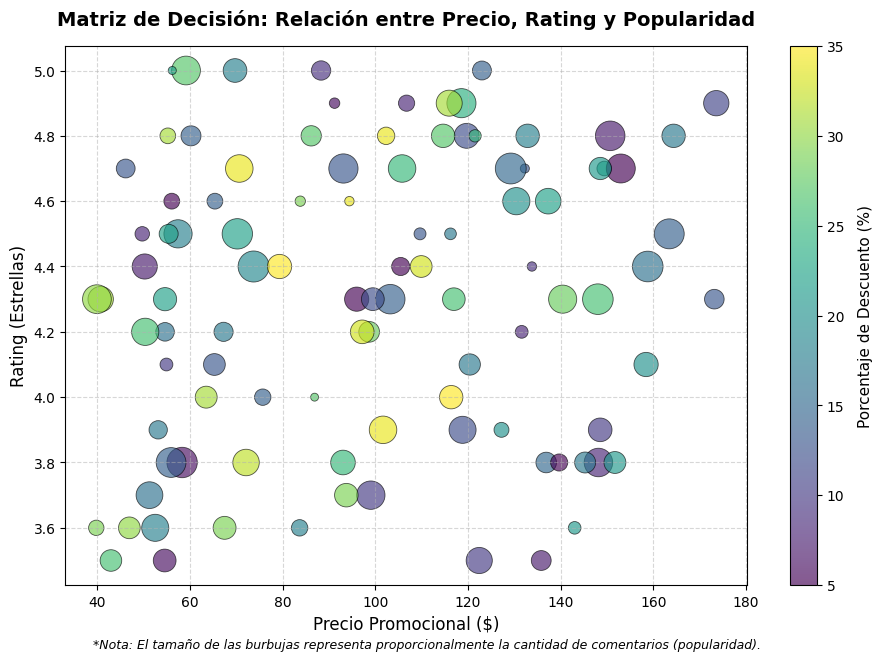

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ============================================================
# NUEVO GRÁFICO: MATRIZ MULTIDIMENSIONAL DE DECISIÓN DE COMPRA
# Relación entre Precio, Rating, Comentarios y Descuento
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 7))

# Escalamos el tamaño de los comentarios para que las burbujas sean legibles
# (Mapea los tamaños entre un mínimo de 30 y un máximo de 500)
tamaños_burbuja = 30 + (df_precio["comentarios_num"] / df_precio["comentarios_num"].max()) * 470

# Crear el gráfico de dispersión (Scatter Plot)
scatter = plt.scatter(
    df_precio["precio_promocion_num"],
    df_precio["rating"],
    s=tamaños_burbuja,
    c=df_precio["porcentaje_descuento"],
    cmap="viridis",         # Paleta de colores atractiva
    alpha=0.65,             # Transparencia para ver burbujas superpuestas
    edgecolors="black",     # Borde de las burbujas
    linewidths=0.6
)

# Añadir la barra de color (Colorbar) para el descuento
cbar = plt.colorbar(scatter)
cbar.set_label("Porcentaje de Descuento (%)", fontsize=11, labelpad=10)

# Títulos y etiquetas descriptivas
plt.title("Matriz de Decisión: Relación entre Precio, Rating y Popularidad", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Precio Promocional ($)", fontsize=12)
plt.ylabel("Rating (Estrellas)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

# Nota aclaratoria sobre el tamaño
plt.figtext(0.15, 0.02, "*Nota: El tamaño de las burbujas representa proporcionalmente la cantidad de comentarios (popularidad).",
            fontsize=9, style='italic')

plt.show()

### Interpretación sugerida para tu documento:
El gráfico multidimensional permite evaluar de manera simultánea los factores clave en la decisión de compra. Las burbujas situadas en la parte superior izquierda representan la opción ideal: productos con un precio accesible y un alto rating de satisfacción. Al mismo tiempo, el tamaño de la burbuja nos indica el nivel de validación social (comentarios) y el color nos permite discernir si la oferta actual cuenta con un descuento agresivo respecto a su precio original.

## Mapa de Calor de Correlación (Correlation Heatmap)
Si buscas darle un enfoque estadístico más riguroso a tu entrega, este gráfico utiliza la librería seaborn para mostrar el coeficiente de correlación de Pearson entre todas las variables numéricas. Te servirá para demostrar si existe alguna relación real entre, por ejemplo, tener un precio más alto y recibir mejores calificaciones de estrellas.

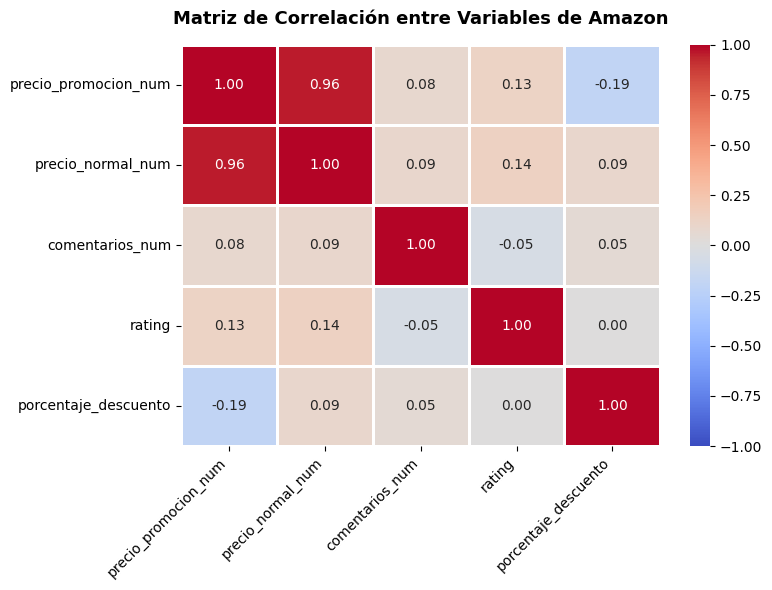

In [30]:
# ============================================================
# NUEVO GRÁFICO: MAPA DE CALOR DE CORRELACIÓN DE VARIABLES
# Análisis estadístico de interdependencia
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Seleccionamos las columnas numéricas clave para calcular su correlación
columnas_analisis = [
    "precio_promocion_num",
    "precio_normal_num",
    "comentarios_num",
    "rating",
    "porcentaje_descuento"
]
matriz_corr = df_precio[columnas_analisis].corr()

# Dibujar el mapa de calor (Heatmap)
sns.heatmap(
    matriz_corr,
    annot=True,          # Muestra los coeficientes numéricos dentro de cada celda
    cmap="coolwarm",     # Escala de azules (negativo) a rojos (positivo)
    fmt=".2f",           # Redondeo a 2 decimales
    linewidths=0.8,      # Espacio de separación entre celdas
    vmin=-1,             # Límite mínimo de la correlación
    vmax=1               # Límite máximo de la correlación
)

plt.title("Matriz de Correlación entre Variables de Amazon", fontsize=13, pad=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

## Interpretación sugerida para tu documento:
El mapa de calor presenta los coeficientes de correlación entre las distintas métricas recopiladas. Los valores cercanos a $1.00$ denotan una correlación positiva fuerte, mientras que valores cercanos a $-1.00$ indican una relación inversa. Este gráfico ayuda a validar hipótesis comerciales, como verificar si los productos con mayores descuentos atraen de manera significativa un mayor volumen de comentarios o si el precio está ligado linealmente a la percepción de calidad del usuario ($rating$).